# INSURANCE ANTI-FRAUD DETECTION
## Xây dựng và so sánh các mô hình phân loại: KNN, Logistic Regression, Naive Bayes, Decision Tree, Random Forest

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["figure.dpi"] = 100

%matplotlib inline

## 1. Đọc và khám phá dữ liệu (EDA)

Bộ dữ liệu gồm 1000 quan sát, 40 cột (39 biến gốc + 1 cột rỗng `_c39`). Biến mục tiêu là `fraud_reported` (Y/N).

In [ ]:
df = pd.read_csv("insurance_claims.csv")
print("Kích thước dữ liệu:", df.shape)
df.head()

Kích thước dữ liệu: (1000, 40)


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   str    
 4   policy_state                 1000 non-null   str    
 5   policy_csl                   1000 non-null   str    
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   str    
 11  insured_education_level      1000 non-null   str    
 12  insured_occupation           1000 non-null   str    
 13  insured_hobbies              1

In [ ]:
# Cột _c39 hoàn toàn rỗng -> loại bỏ
df = df.drop(columns=["_c39"])

# Phân bố biến mục tiêu
print(df["fraud_reported"].value_counts())
print(df["fraud_reported"].value_counts(normalize=True).round(3))

fraud_reported
N    753
Y    247
Name: count, dtype: int64
fraud_reported
N    0.753
Y    0.247
Name: proportion, dtype: float64


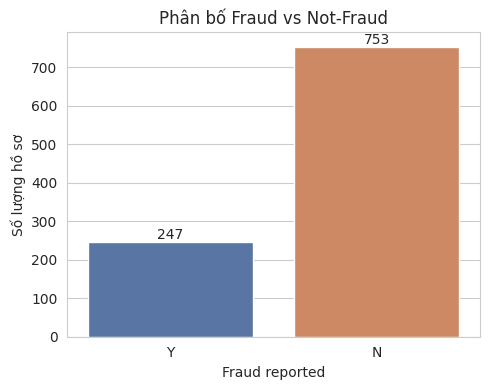

=> Dữ liệu MẤT CÂN BẰNG: ~75% Not Fraud vs ~25% Fraud.
   Vì vậy Accuracy sẽ không phải là chỉ số đánh giá đáng tin cậy nhất; cần quan tâm thêm Precision/Recall/F1/AUC cho lớp Fraud.


In [ ]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(x="fraud_reported", data=df, palette=["#4C72B0", "#DD8452"])
plt.title("Phân bố Fraud vs Not-Fraud")
plt.xlabel("Fraud reported")
plt.ylabel("Số lượng hồ sơ")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

print("=> Dữ liệu MẤT CÂN BẰNG: ~75% Not Fraud vs ~25% Fraud."
      "\n   Vì vậy Accuracy sẽ không phải là chỉ số đánh giá đáng tin cậy nhất;"
      " cần quan tâm thêm Precision/Recall/F1/AUC cho lớp Fraud.")

## 2. Tiền xử lý dữ liệu

In [ ]:
# 2.1 Xử lý giá trị '?' -> nhóm riêng "UNKNOWN"
for col in ["collision_type", "property_damage", "police_report_available"]:
    n_missing = (df[col] == "?").sum()
    print(f"Cột '{col}': {n_missing} giá trị '?' -> gán nhãn 'UNKNOWN'")
    df[col] = df[col].replace("?", "UNKNOWN")

Cột 'collision_type': 178 giá trị '?' -> gán nhãn 'UNKNOWN'
Cột 'property_damage': 360 giá trị '?' -> gán nhãn 'UNKNOWN'
Cột 'police_report_available': 343 giá trị '?' -> gán nhãn 'UNKNOWN'


In [ ]:
# 2.2 Loại bỏ các cột định danh / cardinality quá cao
drop_cols = [
    "policy_number", "policy_bind_date", "incident_date",
    "insured_zip", "incident_location", "auto_model",
]
df = df.drop(columns=drop_cols)
print("Đã loại bỏ:", drop_cols)
print("Kích thước còn lại:", df.shape)

Đã loại bỏ: ['policy_number', 'policy_bind_date', 'incident_date', 'insured_zip', 'incident_location', 'auto_model']
Kích thước còn lại: (1000, 33)


In [ ]:
# 2.3 Mã hoá biến mục tiêu
df["fraud_reported"] = df["fraud_reported"].map({"Y": 1, "N": 0})

# 2.4 Feature engineering: tỉ lệ các loại claim trên tổng claim
df["injury_claim_ratio"] = df["injury_claim"] / df["total_claim_amount"].replace(0, np.nan)
df["property_claim_ratio"] = df["property_claim"] / df["total_claim_amount"].replace(0, np.nan)
df["vehicle_claim_ratio"] = df["vehicle_claim"] / df["total_claim_amount"].replace(0, np.nan)
df[["injury_claim_ratio", "property_claim_ratio", "vehicle_claim_ratio"]] = \
    df[["injury_claim_ratio", "property_claim_ratio", "vehicle_claim_ratio"]].fillna(0)

target = "fraud_reported"
cat_cols = df.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in df.columns if c not in cat_cols + [target]]
print(f"Số cột phân loại (one-hot): {len(cat_cols)}")
print(f"Số cột số: {len(num_cols)}")

Số cột phân loại (one-hot): 16
Số cột số: 19


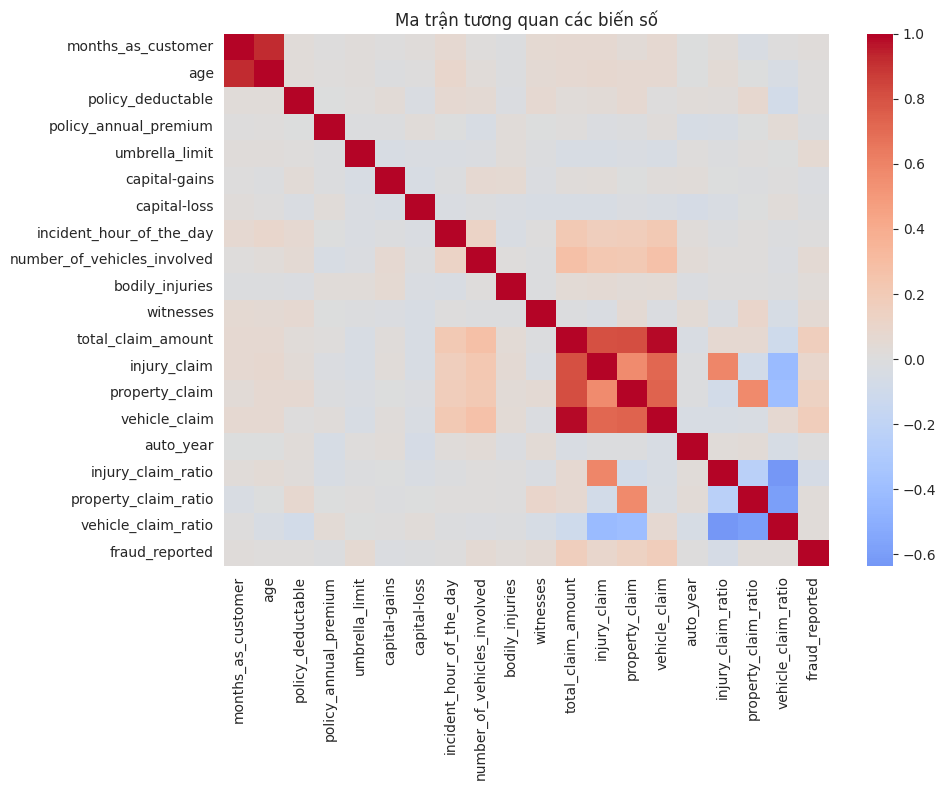

In [ ]:
# Ma trận tương quan giữa các biến số gốc
plt.figure(figsize=(10, 8))
corr = df[num_cols + [target]].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Ma trận tương quan các biến số")
plt.tight_layout()
plt.show()

In [ ]:
# 2.5 One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print("Kích thước sau one-hot encoding:", df_encoded.shape)

X = df_encoded.drop(columns=[target])
y = df_encoded[target]
feature_names_full = X.columns.tolist()

Kích thước sau one-hot encoding: (1000, 109)


## 3. Chia tập Train/Test (80/20)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Tỉ lệ fraud - train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")

Train: (800, 108), Test: (200, 108)
Tỉ lệ fraud - train: 0.247 | test: 0.245


## 4. Feature Selection (giảm chiều dữ liệu)


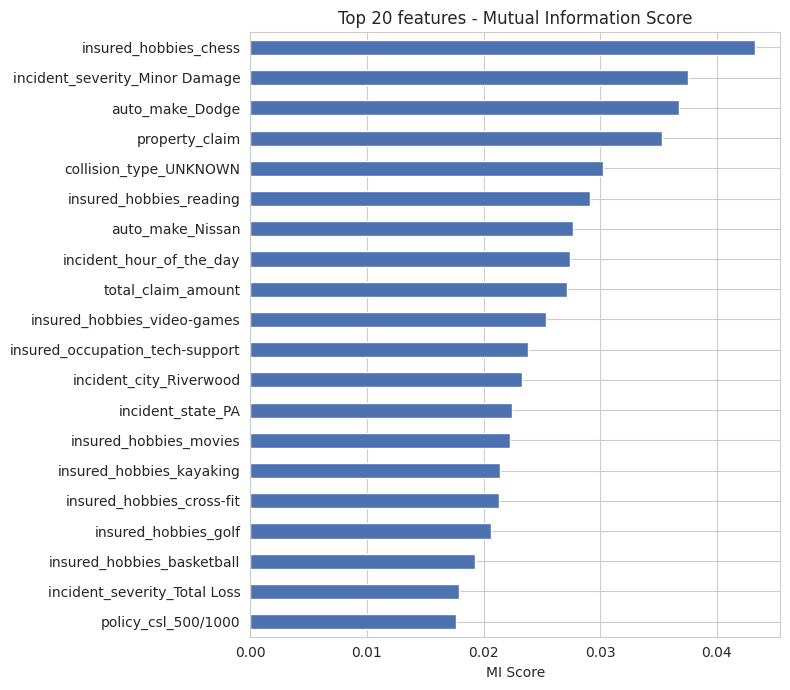

Đã giảm từ 108 xuống 20 đặc trưng.


In [ ]:
K_BEST = 20
selector = SelectKBest(score_func=mutual_info_classif, k=K_BEST)
selector.fit(X_train, y_train)

mi_scores = pd.Series(selector.scores_, index=feature_names_full).sort_values(ascending=False)
selected_features = mi_scores.head(K_BEST).index.tolist()

X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

plt.figure(figsize=(8, 7))
mi_scores.head(K_BEST).sort_values().plot(kind="barh", color="#4C72B0")
plt.title(f"Top {K_BEST} features - Mutual Information Score")
plt.xlabel("MI Score")
plt.tight_layout()
plt.show()

print(f"Đã giảm từ {len(feature_names_full)} xuống {K_BEST} đặc trưng.")

## 5. Chuẩn hoá dữ liệu (Scaling)

In [ ]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_sel), columns=selected_features, index=X_train_sel.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_sel), columns=selected_features, index=X_test_sel.index)
print("Đã chuẩn hoá xong.")

Đã chuẩn hoá xong.


## 6. Huấn luyện 5 mô hình phân loại


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}
fitted_models = {}
roc_data = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)
    auc = roc_auc_score(y_te, y_proba) if y_proba is not None else np.nan

    print(f"--- {name} ---")
    print(classification_report(y_te, y_pred, target_names=["Not Fraud", "Fraud"], zero_division=0))
    print(f"Accuracy={acc:.3f} | Precision={prec:.3f} | Recall={rec:.3f} | F1={f1:.3f} | AUC={auc:.3f}")

    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "AUC": auc}
    fitted_models[name] = model
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_te, y_proba)
        roc_data[name] = (fpr, tpr, auc)

    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(4, 3.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Not Fraud", "Fraud"], yticklabels=["Not Fraud", "Fraud"])
    plt.title(f"Confusion Matrix - {name}")
    plt.ylabel("Thực tế"); plt.xlabel("Dự đoán")
    plt.tight_layout()
    plt.show()
    return model

### 6.1. K-Nearest Neighbors (KNN)

KNN best params: {'n_neighbors': 9, 'weights': 'uniform'}
--- KNN ---
              precision    recall  f1-score   support

   Not Fraud       0.85      0.88      0.86       151
       Fraud       0.58      0.51      0.54        49

    accuracy                           0.79       200
   macro avg       0.71      0.70      0.70       200
weighted avg       0.78      0.79      0.79       200

Accuracy=0.790 | Precision=0.581 | Recall=0.510 | F1=0.543 | AUC=0.784


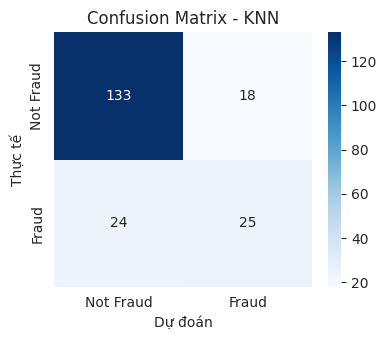

In [ ]:
knn_grid = GridSearchCV(KNeighborsClassifier(),
                         param_grid={"n_neighbors": [3, 5, 7, 9, 11, 15],
                                     "weights": ["uniform", "distance"]},
                         cv=cv, scoring="f1", n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)
print("KNN best params:", knn_grid.best_params_)
evaluate_model("KNN", knn_grid.best_estimator_, X_train_scaled, X_test_scaled, y_train, y_test);

### 6.2. Logistic Regression

Logistic Regression best params: {'C': 1, 'class_weight': 'balanced'}
--- Logistic Regression ---
              precision    recall  f1-score   support

   Not Fraud       0.95      0.84      0.89       151
       Fraud       0.64      0.86      0.73        49

    accuracy                           0.84       200
   macro avg       0.79      0.85      0.81       200
weighted avg       0.87      0.84      0.85       200

Accuracy=0.845 | Precision=0.636 | Recall=0.857 | F1=0.730 | AUC=0.834


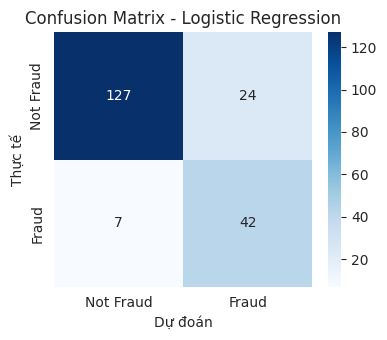

In [ ]:
logreg_grid = GridSearchCV(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
                            param_grid={"C": [0.01, 0.1, 1, 10], "class_weight": [None, "balanced"]},
                            cv=cv, scoring="f1", n_jobs=-1)
logreg_grid.fit(X_train_scaled, y_train)
print("Logistic Regression best params:", logreg_grid.best_params_)
evaluate_model("Logistic Regression", logreg_grid.best_estimator_, X_train_scaled, X_test_scaled, y_train, y_test);

### 6.3. Naive Bayes (Gaussian)

--- Naive Bayes ---
              precision    recall  f1-score   support

   Not Fraud       0.83      0.92      0.87       151
       Fraud       0.62      0.41      0.49        49

    accuracy                           0.80       200
   macro avg       0.73      0.66      0.68       200
weighted avg       0.78      0.80      0.78       200

Accuracy=0.795 | Precision=0.625 | Recall=0.408 | F1=0.494 | AUC=0.720


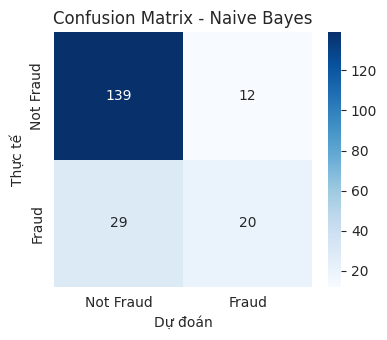

In [ ]:
nb = GaussianNB()
evaluate_model("Naive Bayes", nb, X_train_scaled, X_test_scaled, y_train, y_test);

### 6.4. Decision Tree

Decision Tree best params: {'class_weight': 'balanced', 'max_depth': 4, 'min_samples_leaf': 1}
--- Decision Tree ---
              precision    recall  f1-score   support

   Not Fraud       0.93      0.85      0.89       151
       Fraud       0.65      0.82      0.72        49

    accuracy                           0.84       200
   macro avg       0.79      0.84      0.81       200
weighted avg       0.86      0.84      0.85       200

Accuracy=0.845 | Precision=0.645 | Recall=0.816 | F1=0.721 | AUC=0.841


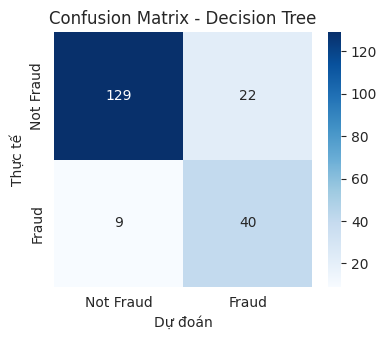

In [ ]:
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE),
                        param_grid={"max_depth": [3, 4, 5, 6, 8, 10],
                                    "min_samples_leaf": [1, 5, 10, 20],
                                    "class_weight": [None, "balanced"]},
                        cv=cv, scoring="f1", n_jobs=-1)
dt_grid.fit(X_train_sel, y_train)  # cây quyết định không cần scaling
print("Decision Tree best params:", dt_grid.best_params_)
evaluate_model("Decision Tree", dt_grid.best_estimator_, X_train_sel, X_test_sel, y_train, y_test);

### 6.5. Random Forest

Random Forest best params: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 1}


--- Random Forest ---
              precision    recall  f1-score   support

   Not Fraud       0.95      0.85      0.90       151
       Fraud       0.65      0.86      0.74        49

    accuracy                           0.85       200
   macro avg       0.80      0.85      0.82       200
weighted avg       0.87      0.85      0.86       200

Accuracy=0.850 | Precision=0.646 | Recall=0.857 | F1=0.737 | AUC=0.828


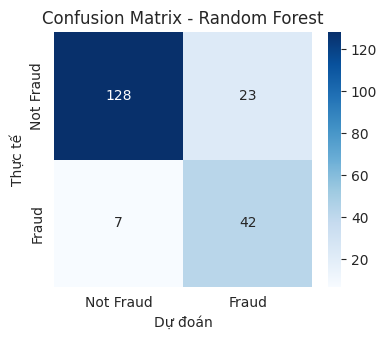

In [ ]:
rf_grid = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=300),
                        param_grid={"max_depth": [5, 8, 12, None],
                                    "min_samples_leaf": [1, 5, 10],
                                    "class_weight": [None, "balanced"]},
                        cv=cv, scoring="f1", n_jobs=-1)
rf_grid.fit(X_train_sel, y_train)
print("Random Forest best params:", rf_grid.best_params_)
evaluate_model("Random Forest", rf_grid.best_estimator_, X_train_sel, X_test_sel, y_train, y_test);

## 7. So sánh hiệu năng các mô hình

In [ ]:
results_df = pd.DataFrame(results).T.sort_values("F1", ascending=False).round(3)
results_df

,Accuracy,Precision,Recall,F1,AUC
Random Forest,0.850,0.646,0.857,0.737,0.828
Logistic Regression,0.845,0.636,0.857,0.730,0.834
Decision Tree,0.845,0.645,0.816,0.721,0.841
KNN,0.790,0.581,0.510,0.543,0.784
Naive Bayes,0.795,0.625,0.408,0.494,0.720


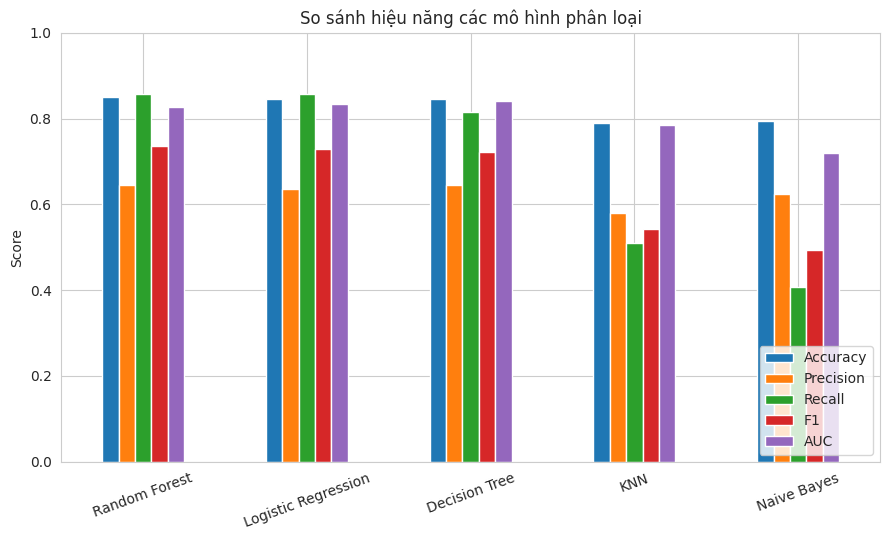

In [ ]:
# Biểu đồ so sánh
ax = results_df[["Accuracy", "Precision", "Recall", "F1", "AUC"]].plot(kind="bar", figsize=(9, 5.5))
plt.title("So sánh hiệu năng các mô hình phân loại")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

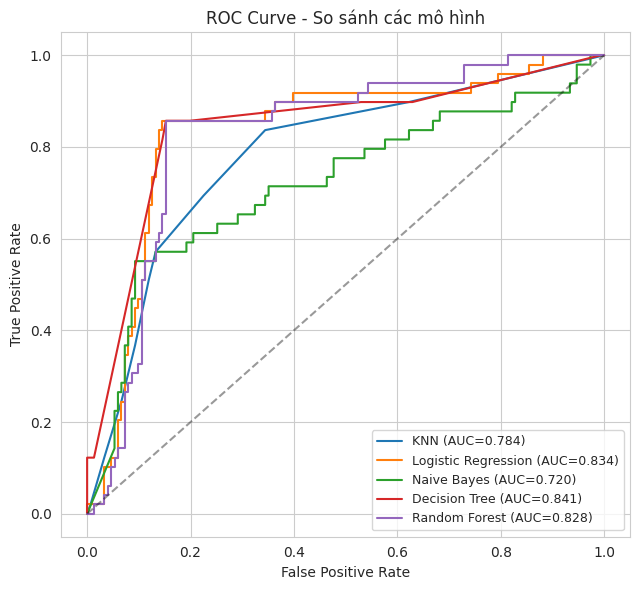

In [ ]:
# ROC curves
plt.figure(figsize=(6.5, 6))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - So sánh các mô hình")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

**Nhận xét:**
- Vì dữ liệu mất cân bằng (~75% Not Fraud), **Accuracy không phải chỉ số đáng tin cậy nhất**, một mô hình luôn dự đoán "Not Fraud" vẫn đạt Accuracy ~75%. Recall/F1/AUC cho lớp Fraud quan trọng hơn.
- **Decision Tree** (class_weight cân bằng) đạt **Recall cao nhất**, phát hiện được phần lớn ca gian lận, đánh đổi bằng Precision thấp hơn.
- **Random Forest** có AUC gần tương đương Decision Tree nhưng ổn định hơn nhờ ensemble nhiều cây.
- **Naive Bayes** và **KNN** có Recall thấp, dễ bỏ sót ca gian lận thật dù Accuracy tổng thể trông cao.
- Trong bài toán phát hiện gian lận (chi phí bỏ sót 1 ca gian lận > chi phí điều tra nhầm), **Decision Tree và Random Forest là lựa chọn phù hợp hơn**.

## 8. Trực quan hoá cây quyết định

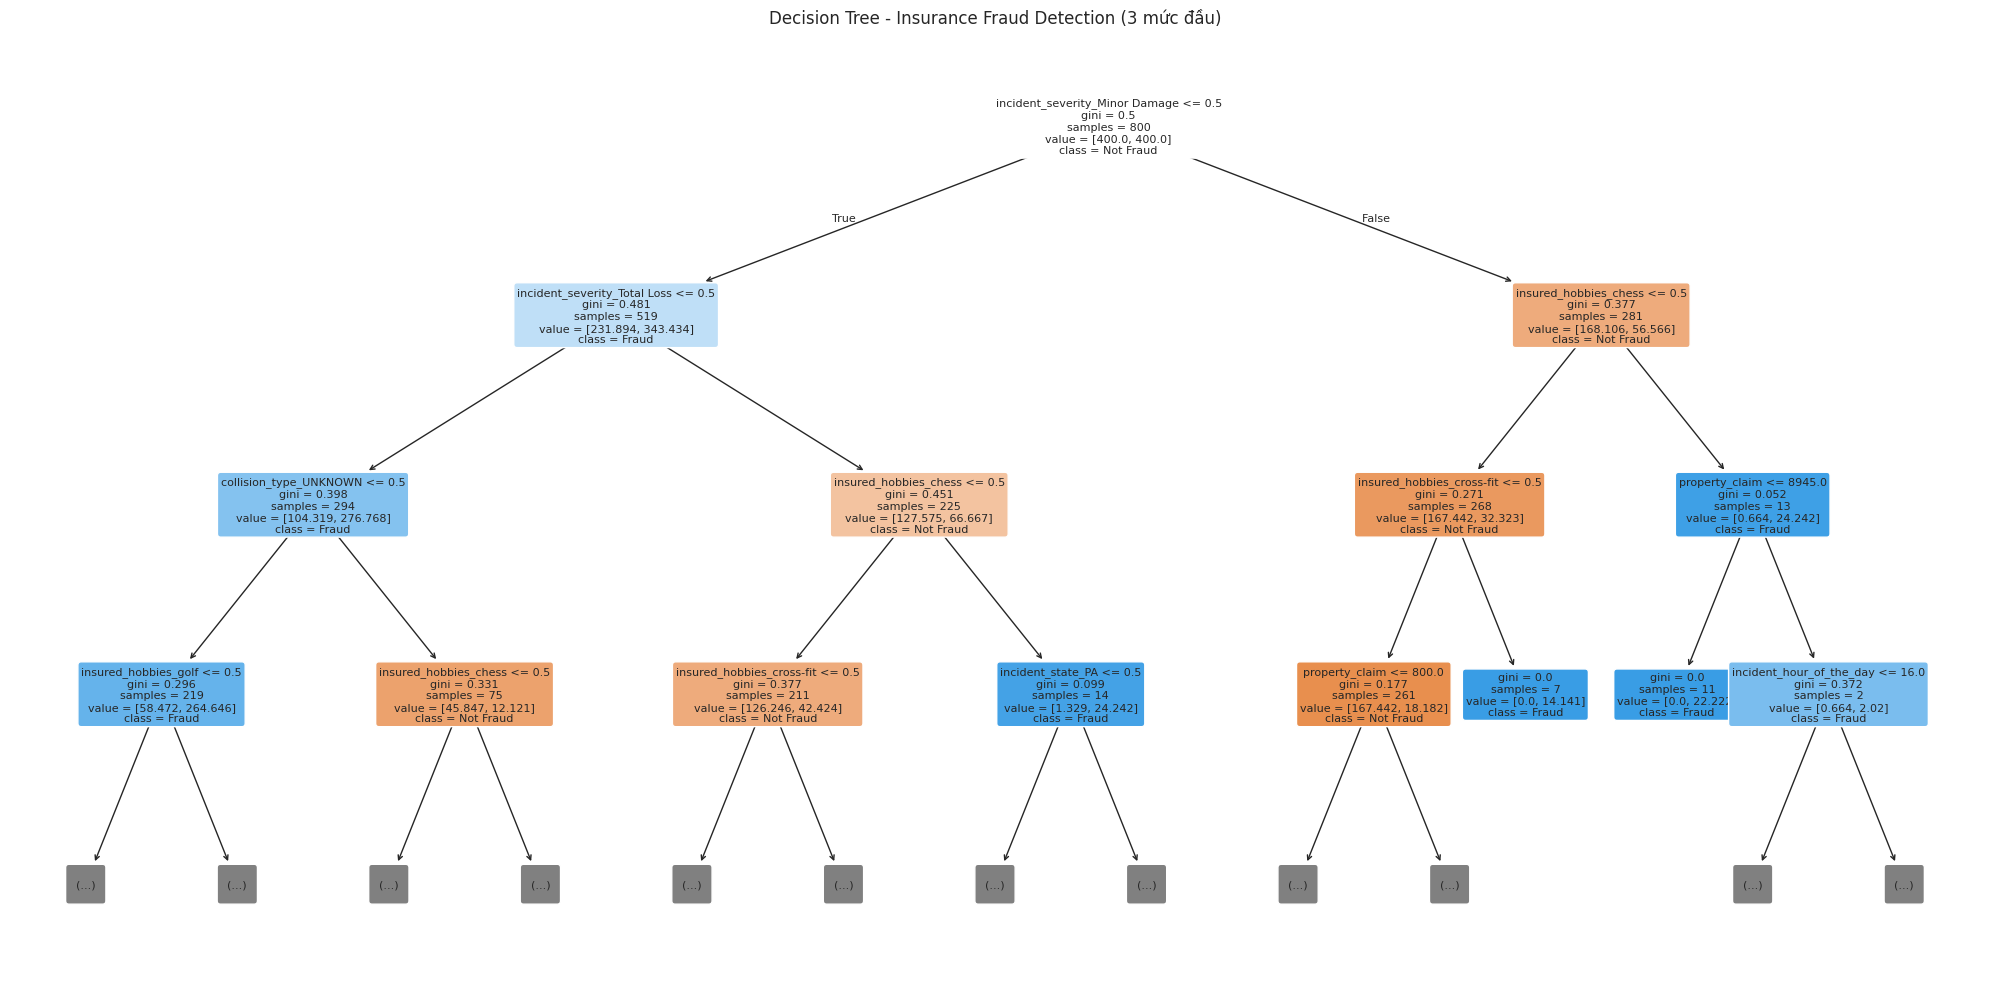

Độ sâu thực tế của cây: 4 | Số lá: 14


In [ ]:
best_dt = dt_grid.best_estimator_
plt.figure(figsize=(20, 10))
plot_tree(best_dt, feature_names=selected_features, class_names=["Not Fraud", "Fraud"],
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title("Decision Tree - Insurance Fraud Detection (3 mức đầu)")
plt.tight_layout()
plt.show()

print(f"Độ sâu thực tế của cây: {best_dt.get_depth()} | Số lá: {best_dt.get_n_leaves()}")

## 9. Feature Importance


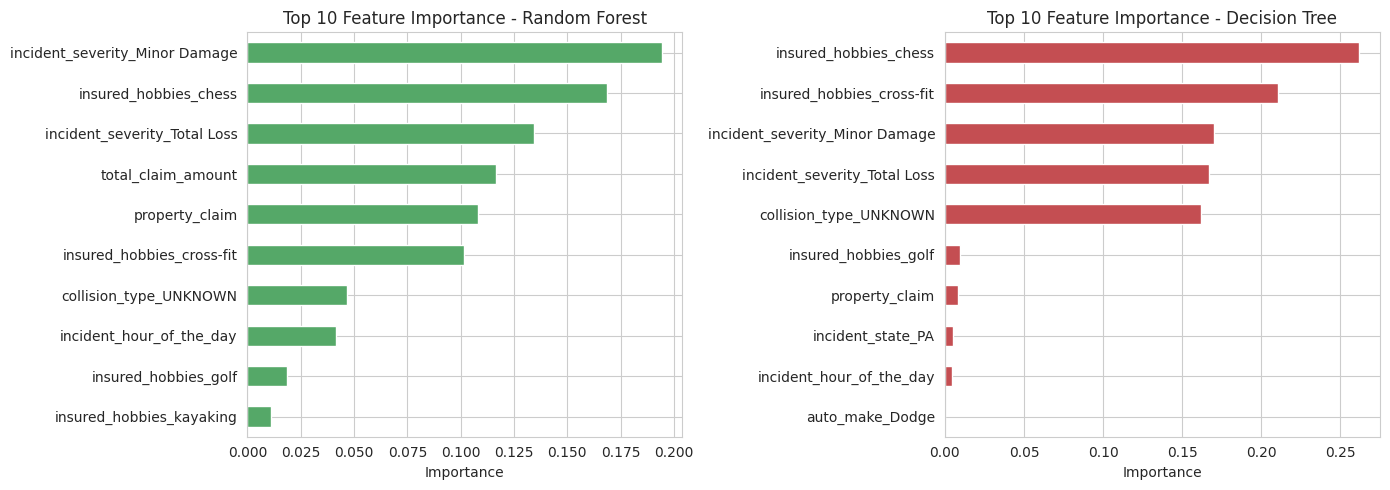

In [ ]:
rf_importance = pd.Series(rf_grid.best_estimator_.feature_importances_,
                           index=selected_features).sort_values(ascending=False)
dt_importance = pd.Series(best_dt.feature_importances_,
                           index=selected_features).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rf_importance.head(10).sort_values().plot(kind="barh", color="#55A868", ax=axes[0])
axes[0].set_title("Top 10 Feature Importance - Random Forest")
axes[0].set_xlabel("Importance")

dt_importance.head(10).sort_values().plot(kind="barh", color="#C44E52", ax=axes[1])
axes[1].set_title("Top 10 Feature Importance - Decision Tree")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

## 10. Kết luận

### Top 5 features quan trọng nhất (Random Forest)

In [ ]:
top5_rf = rf_importance.head(5).reset_index()
top5_rf.columns = ["Feature", "Importance"]
top5_rf.insert(0, "Hạng", range(1, 6))
top5_rf["Ý nghĩa"] = [
    "Mức độ nghiêm trọng của vụ va chạm là \"Hư hỏng nhẹ\"",
    "Sở thích của người được bảo hiểm là cờ vua",
    "Số tiền yêu cầu bồi thường tài sản",
    "Tổng số tiền yêu cầu bồi thường",
    "Sở thích của người được bảo hiểm là cross-fit",
]
top5_rf = top5_rf[["Hạng", "Feature", "Ý nghĩa", "Importance"]]
top5_rf["Importance"] = top5_rf["Importance"].round(4)
top5_rf

,Hạng,Feature,Ý nghĩa,Importance
0,1,incident_severity_Minor Damage,"Mức độ nghiêm trọng của vụ va chạm là ""Hư hỏng...",0.1943
1,2,insured_hobbies_chess,Sở thích của người được bảo hiểm là cờ vua,0.1686
2,3,incident_severity_Total Loss,Số tiền yêu cầu bồi thường tài sản,0.1344
3,4,total_claim_amount,Tổng số tiền yêu cầu bồi thường,0.1167
4,5,property_claim,Sở thích của người được bảo hiểm là cross-fit,0.1080


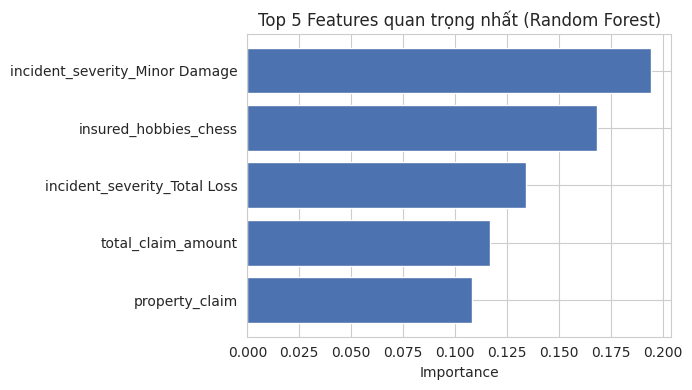

In [ ]:
plt.figure(figsize=(7, 4))
plt.barh(top5_rf["Feature"][::-1], top5_rf["Importance"][::-1], color="#4C72B0")
plt.title("Top 5 Features quan trọng nhất (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Tổng kết

**Kết quả chính:**
- **Decision Tree** và **Random Forest** cho hiệu năng phát hiện gian lận (Recall, AUC) tốt nhất trong 5 mô hình thử nghiệm.
- **5 đặc trưng quan trọng nhất**: `incident_severity_Minor Damage`, `insured_hobbies_chess`, `property_claim`, `total_claim_amount`, `insured_hobbies_cross-fit` (bảng và biểu đồ ở trên).
- Do dữ liệu mất cân bằng (~75/25), việc dùng `class_weight='balanced'` và đánh giá qua F1/Recall/AUC thay vì chỉ Accuracy là cần thiết.